In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/daily-social-media-active-users/Social Media Users.csv


## Title: Daily Social Media Users

## Description: 
Track the number of active users engaging on social media platforms each day.










## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/daily-social-media-active-users/Social Media Users.csv')

In [3]:
df.head()

,Platform,Owner,Primary Usage,Country,Daily Time Spent (min),Verified Account,Date Joined
0,WhatsApp,Meta,Messaging,Switzerland,113.94,Yes,2019-03-03
1,WeChat,Tencent,Messaging and social media,Madagascar,49.63,Yes,2023-09-21
2,Snapchat,Snap Inc.,Multimedia messaging,Pitcairn Islands,29.01,Yes,2020-12-13
3,Instagram,Meta,Photo and video sharing,Timor-Leste,295.43,Yes,2019-04-21
4,Threads,Meta,Text-based social networking,Bermuda,71.78,No,2015-07-14


In [4]:
df.tail()

,Platform,Owner,Primary Usage,Country,Daily Time Spent (min),Verified Account,Date Joined
9995,Pinterest,Pinterest Inc.,Visual discovery and bookmarking,Morocco,249.12,No,2024-04-23
9996,Reddit,Reddit Inc.,Discussion forums and communities,Cape Verde,111.38,Yes,2017-03-06
9997,Quora,Quora Inc.,Q&A knowledge sharing,Poland,87.88,No,2018-05-17
9998,Quora,Quora Inc.,Q&A knowledge sharing,Lao People's Democratic Republic,205.69,Yes,2019-10-07
9999,Reddit,Reddit Inc.,Discussion forums and communities,Faroe Islands,272.93,Yes,2015-08-03


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Platform                10000 non-null  object 
 1   Owner                   10000 non-null  object 
 2   Primary Usage           10000 non-null  object 
 3   Country                 10000 non-null  object 
 4   Daily Time Spent (min)  10000 non-null  float64
 5   Verified Account        10000 non-null  object 
 6   Date Joined             10000 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.0+ KB


In [6]:
df.describe()

,Daily Time Spent (min)
count,10000.000000
mean,152.211145
std,85.142750
min,5.020000
25%,78.920000
50%,152.735000
75%,225.642500
max,300.000000


In [7]:
df.isnull().sum()

Platform                  0
Owner                     0
Primary Usage             0
Country                   0
Daily Time Spent (min)    0
Verified Account          0
Date Joined               0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(10000, 7)

In [10]:
df.dtypes

Platform                   object
Owner                      object
Primary Usage              object
Country                    object
Daily Time Spent (min)    float64
Verified Account           object
Date Joined                object
dtype: object

In [11]:
df.columns

Index(['Platform', 'Owner', 'Primary Usage', 'Country',
       'Daily Time Spent (min)', 'Verified Account', 'Date Joined'],
      dtype='object')

## Data visualizations

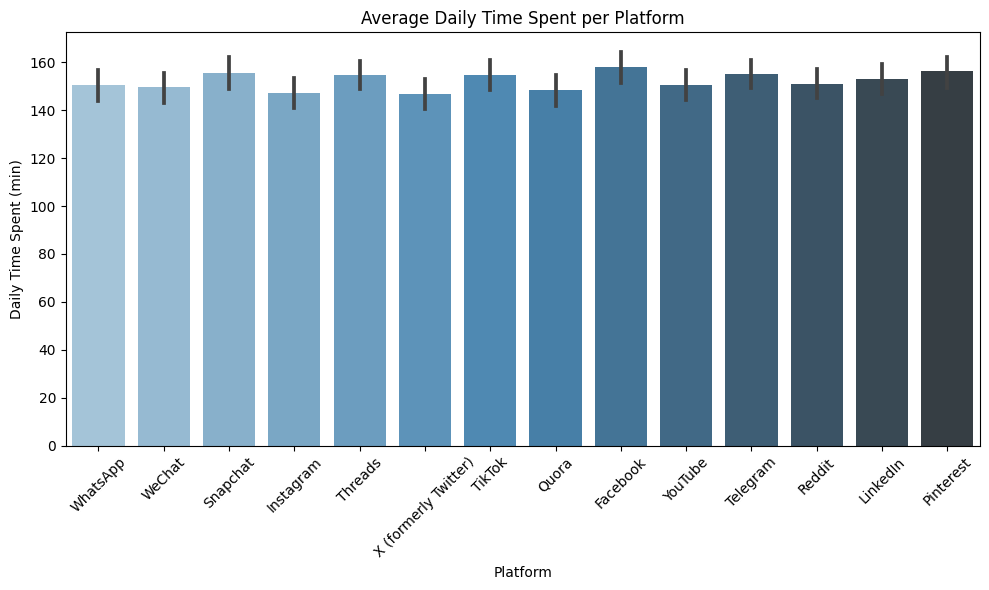

In [12]:
# 1. Bar Chart: Average Daily Time per Platform
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Platform', y='Daily Time Spent (min)', estimator='mean', palette='Blues_d')
plt.title('Average Daily Time Spent per Platform')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

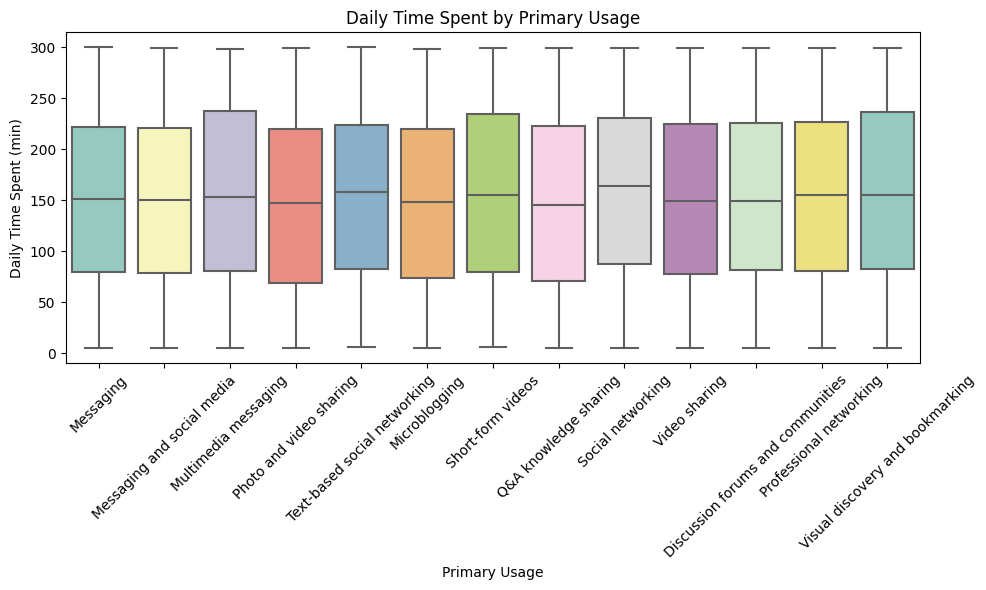

In [13]:
# 2. Box Plot: Daily Time by Primary Usage
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Primary Usage', y='Daily Time Spent (min)', palette='Set3')
plt.title('Daily Time Spent by Primary Usage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

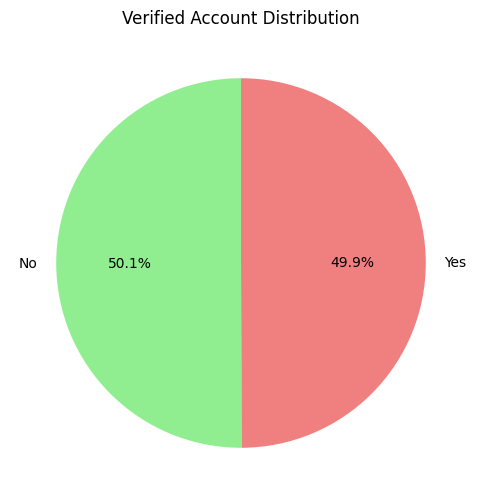

In [14]:
# 3. Pie Chart: Verified Account Distribution
verified_counts = df['Verified Account'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(verified_counts, labels=verified_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'lightcoral'])
plt.title('Verified Account Distribution')
plt.show()

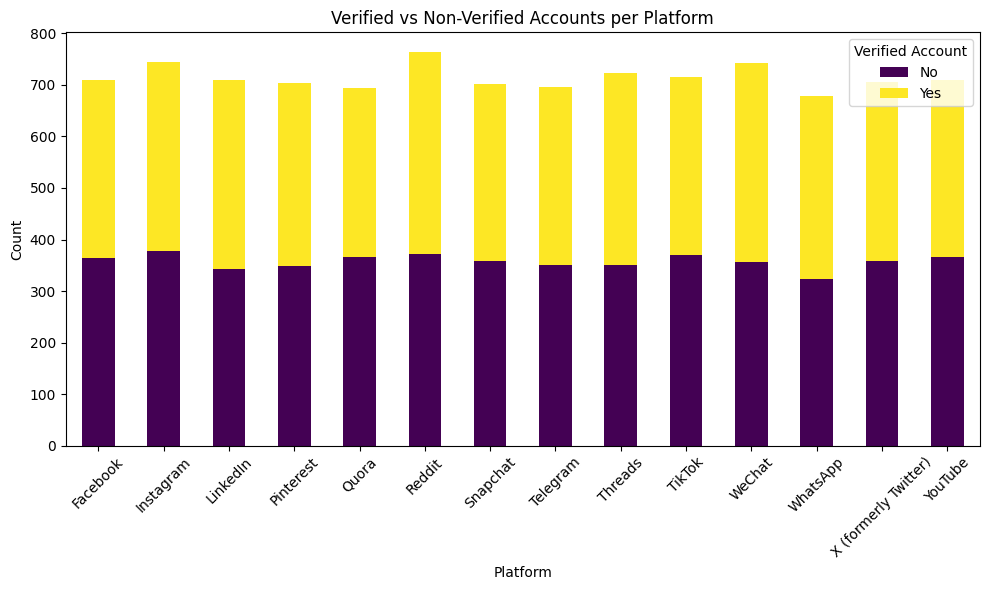

In [15]:
# 4. Stacked Bar Chart: Platform vs Verified Account
platform_verified = df.groupby(['Platform', 'Verified Account']).size().unstack().fillna(0)
platform_verified.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Verified vs Non-Verified Accounts per Platform')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

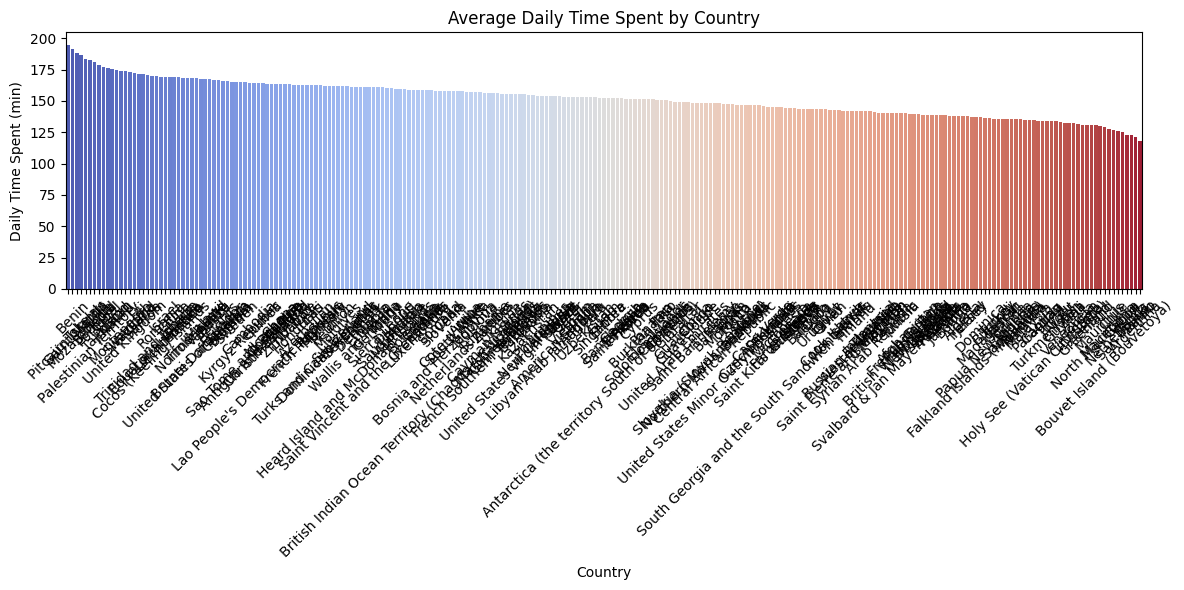

In [16]:
# 5. Bar Chart: Average Time Spent by Country
plt.figure(figsize=(12, 6))
country_time = df.groupby('Country')['Daily Time Spent (min)'].mean().sort_values(ascending=False)
sns.barplot(x=country_time.index, y=country_time.values, palette='coolwarm')
plt.title('Average Daily Time Spent by Country')
plt.ylabel('Daily Time Spent (min)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

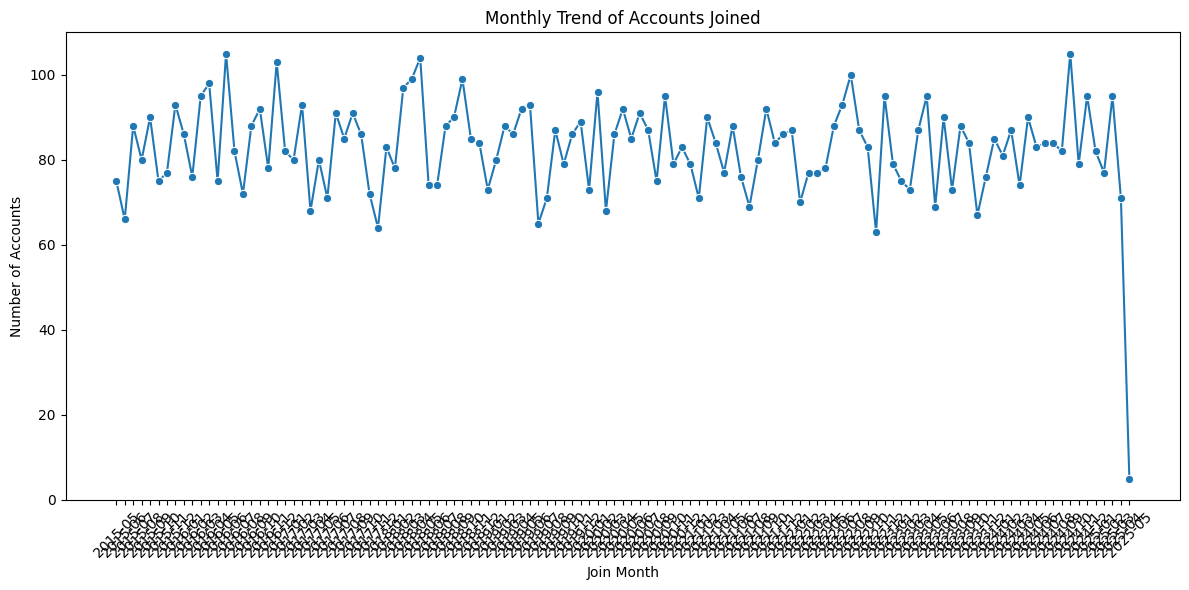

In [17]:
# 6. Line Chart: Number of Accounts Joined Over Time (Monthly)
df['Date Joined'] = pd.to_datetime(df['Date Joined'])
df['Join Month'] = df['Date Joined'].dt.to_period('M').astype(str)
join_trend = df['Join Month'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=join_trend.index, y=join_trend.values, marker='o')
plt.title('Monthly Trend of Accounts Joined')
plt.ylabel('Number of Accounts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Data visualizations

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [19]:
# Drop rows with missing target
df = df.dropna(subset=['Daily Time Spent (min)'])

# Convert Date to Year only
df['Date Joined'] = pd.to_datetime(df['Date Joined'], errors='coerce')
df['JoinYear'] = df['Date Joined'].dt.year
df = df.drop(columns=['Date Joined'])

# Convert target into bins (classification)
bins = [0, 60, 120, df['Daily Time Spent (min)'].max()]
labels = ['Low', 'Medium', 'High']
df['UsageCategory'] = pd.cut(df['Daily Time Spent (min)'], bins=bins, labels=labels)

# Drop original target column
df = df.drop(columns=['Daily Time Spent (min)'])

# Define features and target
X = df.drop(columns=['UsageCategory'])
y = df['UsageCategory']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)



🔍 Logistic Regression
Accuracy: 60.75%
Classification Report:
               precision    recall  f1-score   support

        High       0.61      1.00      0.76      1215
         Low       0.00      0.00      0.00       376
      Medium       0.00      0.00      0.00       409

    accuracy                           0.61      2000
   macro avg       0.20      0.33      0.25      2000
weighted avg       0.37      0.61      0.46      2000



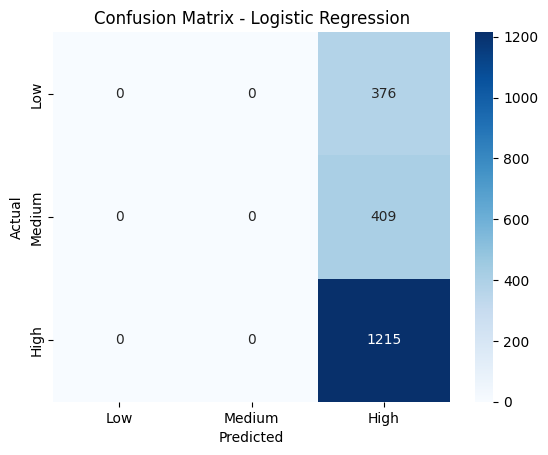


🔍 Random Forest
Accuracy: 57.55%
Classification Report:
               precision    recall  f1-score   support

        High       0.61      0.92      0.73      1215
         Low       0.14      0.03      0.04       376
      Medium       0.24      0.05      0.08       409

    accuracy                           0.58      2000
   macro avg       0.33      0.33      0.29      2000
weighted avg       0.44      0.58      0.47      2000



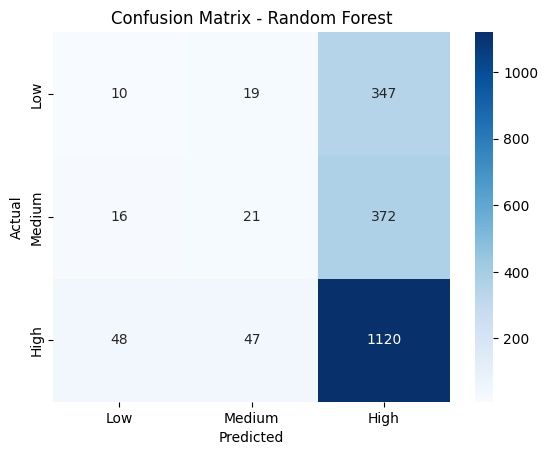


🔍 SVM
Accuracy: 60.75%
Classification Report:
               precision    recall  f1-score   support

        High       0.61      1.00      0.76      1215
         Low       0.00      0.00      0.00       376
      Medium       0.00      0.00      0.00       409

    accuracy                           0.61      2000
   macro avg       0.20      0.33      0.25      2000
weighted avg       0.37      0.61      0.46      2000



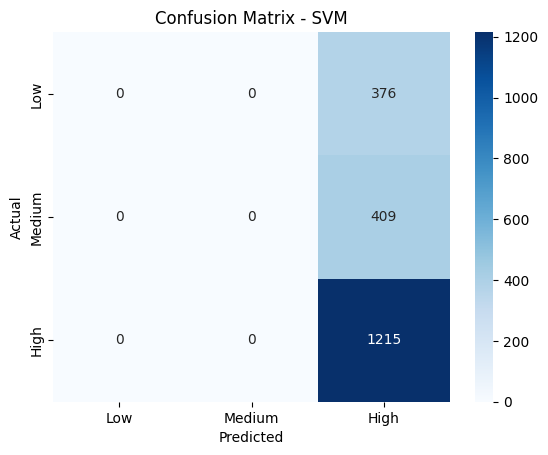


🔍 Decision Tree
Accuracy: 50.10%
Classification Report:
               precision    recall  f1-score   support

        High       0.62      0.70      0.66      1215
         Low       0.22      0.17      0.19       376
      Medium       0.24      0.20      0.22       409

    accuracy                           0.50      2000
   macro avg       0.36      0.36      0.36      2000
weighted avg       0.47      0.50      0.48      2000



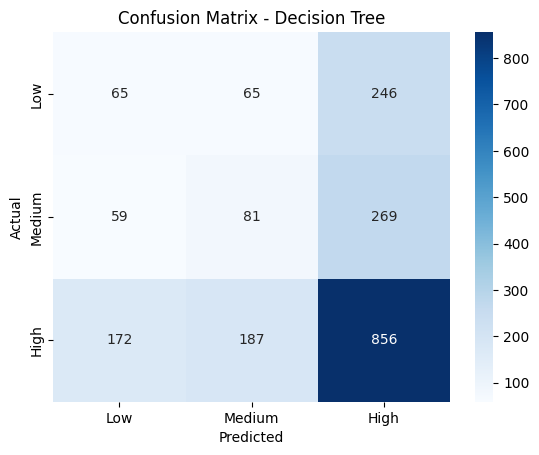


🔍 KNN
Accuracy: 55.25%
Classification Report:
               precision    recall  f1-score   support

        High       0.61      0.86      0.71      1215
         Low       0.18      0.07      0.10       376
      Medium       0.22      0.08      0.11       409

    accuracy                           0.55      2000
   macro avg       0.34      0.34      0.31      2000
weighted avg       0.45      0.55      0.48      2000



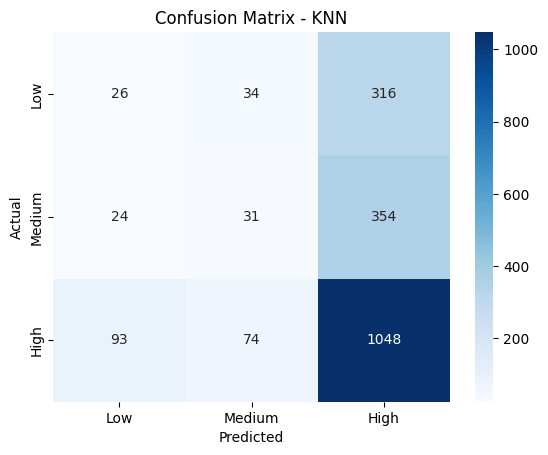

In [20]:
# Categorical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()

# Preprocessing: One-hot encode categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'  # Leave numeric columns as is
)

# Models to test
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

# Evaluate each model
for name, model in models.items():
    print(f"\n🔍 {name}")
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred) * 100
    print(f"Accuracy: {acc:.2f}%")
    print("Classification Report:\n", classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## Thank you..pls upvote!!!